# Liquid Pipe Flow: Pressure Drop, Moody Chart and Economic Diameter

`difflow.fluids` and the `Pipe` unit give differentiable Darcy-Weisbach pressure drops for liquids. This notebook

1. computes the pressure drop of 3 L/s of water in 100 m of 2-in Sch 40 steel pipe,
2. regenerates the Moody chart from `friction_factor` and compares the correlations,
3. finds the economic pipe diameter with `jax.grad`, using `difflow.economics` for the pump.

Liquid density and viscosity are explicit inputs (`rho`, `mu`): core species data carries no liquid transport properties.

In [1]:
import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from difflow import Pipe, PipeParams, make_stream
from difflow.fluids import friction_factor, fully_rough_friction_factor, FITTINGS

RHO, MU, MW = 998.2, 1.002e-3, 18.015      # water, 20 C
D_2IN = 2.067 * 0.0254                      # 2-in Sch 40 inside diameter, m
def water(Q, P=3e5, T=293.15):
    return make_stream({'W': Q * RHO / (MW * 1e-3)}, T, P)

## 1. Pressure drop of a pipe run

In [2]:
pipe = Pipe(PipeParams(L=100.0, D=D_2IN, rho=RHO, mu=MU, MW=MW))   # roughness defaults to 4.6e-5 m
outlet, info = pipe(water(3e-3))
for k in ['v', 'Re', 'f', 'dP_friction', 'head_loss']:
    print(f'{k:12s} {float(info[k]):12.5g}')
print('outlet P  ', float(outlet['P']), 'Pa')

v                  1.3857
Re                  72478
f                0.022542
dP_friction         41149
head_loss          4.2036
outlet P   258850.5056169508 Pa


Fittings, elevation and a different friction correlation are parameters:

In [3]:
fit = Pipe(PipeParams(L=100.0, D=D_2IN, rho=RHO, mu=MU, MW=MW, dz=5.0,
                      fittings={'entrance_sharp': 1, 'elbow_90_standard': 4, 'gate_valve': 1, 'exit': 1},
                      friction_method='churchill'))
_, i2 = fit(water(3e-3))
print({k: round(float(v), 4) for k, v in i2.items()})

{'Q': 0.003, 'v': 1.3857, 'Re': 72478.1374, 'f': 0.0227, 'K_total': 3.9344, 'dP_friction': 41426.5137, 'dP_minor': 3770.7549, 'dP_static': 48944.9902, 'dP': 94142.2587, 'head_loss': 4.6171}


## 2. Moody chart regenerated from the code

Colebrook-White (solid) with the laminar line 64/Re. The dashed lines are Churchill, which agrees with Colebrook to about 2 % for Re > 1e4. Between Re = 2100 and 4000 the Colebrook curve is a smooth interpolation (shaded), not a transition model.

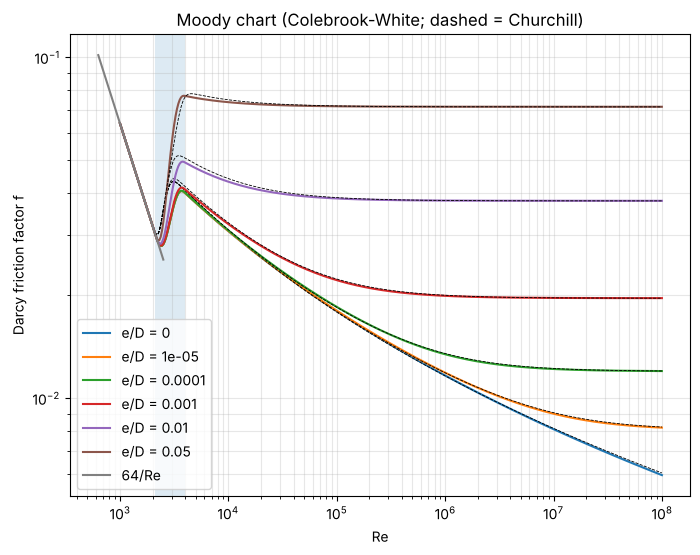

In [4]:
Re = jnp.logspace(3, 8, 400)
fig, ax = plt.subplots(figsize=(8, 6))
for e in [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 0.05]:
    f_c = jax.vmap(lambda r: friction_factor(r, e))(Re)
    f_ch = jax.vmap(lambda r: friction_factor(r, e, 'churchill'))(Re)
    ax.loglog(Re, f_c, label=f'e/D = {e:g}')
    ax.loglog(Re, f_ch, 'k--', lw=0.6)
Rl = jnp.logspace(2.8, 3.4, 20)
ax.loglog(Rl, 64 / Rl, 'gray', label='64/Re')
ax.axvspan(2100, 4000, alpha=0.15)
ax.set_xlabel('Re'); ax.set_ylabel('Darcy friction factor f'); ax.grid(True, which='both', alpha=0.3)
ax.legend(); ax.set_title('Moody chart (Colebrook-White; dashed = Churchill)')
plt.show()

In [5]:
# Spot values against the Moody chart
for Re_, e, ref in [(1e5, 0.0, 0.0180), (1e6, 0.0, 0.0116), (1e9, 0.05, 0.0716), (1e9, 0.001, 0.0196)]:
    print(f'Re={Re_:.0e} e/D={e:<6g} f={float(friction_factor(Re_, e)):.4f}  chart ~ {ref}')
print('f_T for 2-in pipe:', float(fully_rough_friction_factor(4.6e-5 / D_2IN)), '(Crane tabulates 0.019)')

Re=1e+05 e/D=0      f=0.0180  chart ~ 0.018
Re=1e+06 e/D=0      f=0.0116  chart ~ 0.0116
Re=1e+09 e/D=0.05   f=0.0716  chart ~ 0.0716
Re=1e+09 e/D=0.001  f=0.0196  chart ~ 0.0196
f_T for 2-in pipe: 0.019018484174737015 (Crane tabulates 0.019)


## 3. Economic pipe diameter

Annualised cost = piping capital + pump capital + pumping electricity, for 5 L/s over 200 m. Because `Pipe` is differentiable, the optimum is found by gradient descent on the diameter.

**Cost data.** The pump capital cost is `difflow.economics.pump_cost` and the electricity is `pump_electricity_cost`. For the piping we use an *illustrative* power law, cost = `A * (D/0.0254)**B` dollars per metre of installed pipe with A = 60, B = 1.1. That correlation is **a placeholder, not a cited correlation**: the numbers are plausible for installed carbon-steel pipe but come from no source, so replace them with vendor quotes or a cost-data reference (e.g. Peters, Timmerhaus & West, *Plant Design and Economics for Chemical Engineers*) before drawing conclusions. The optimum diameter shifts with those numbers; the method does not.

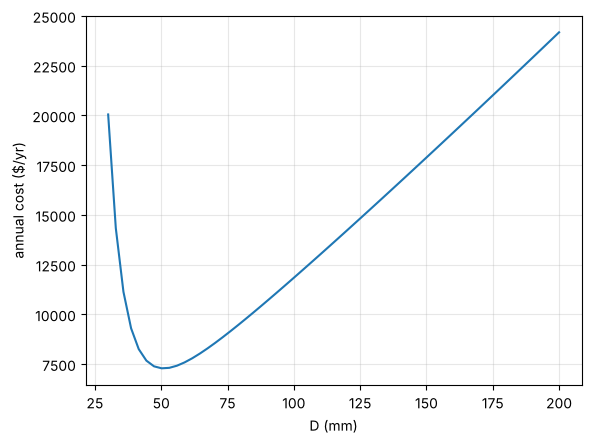

In [6]:
from difflow.economics import pump_cost, pump_electricity_cost

Q, L, ETA = 5e-3, 200.0, 0.7
A, B = 60.0, 1.1               # ILLUSTRATIVE $/m piping cost: A * (D/1 in)**B
ANNUITY, HOURS = 0.2, 8000.0   # capital charge 1/yr, operating hours per year

def annual_cost(D):
    _, info = Pipe(PipeParams(L=L, D=D, rho=RHO, mu=MU, MW=MW, fittings={'elbow_90_standard': 6, 'gate_valve': 2}))(water(Q))
    head = info['dP'] / (RHO * 9.80665)
    power_kW = info['dP'] * Q / ETA / 1e3
    piping = A * (D / 0.0254) ** B * L
    pump = pump_cost(power_kW)
    electricity = pump_electricity_cost(jnp.asarray(Q), head, ETA) * 3600.0 * HOURS
    return ANNUITY * (piping + pump) + electricity

Ds = jnp.linspace(0.03, 0.2, 60)
costs = jax.vmap(annual_cost)(Ds)
plt.plot(Ds * 1000, costs); plt.xlabel('D (mm)'); plt.ylabel('annual cost ($/yr)'); plt.grid(alpha=0.3); plt.show()

In [7]:
# gradient descent on log D with a backtracking-free Newton step using exact derivatives
g = jax.grad(lambda x: annual_cost(jnp.exp(x)))
h = jax.grad(g)
x = jnp.log(0.1)
for _ in range(30):
    x = x - g(x) / h(x)
D_opt = float(jnp.exp(x))
print(f'optimal D = {D_opt*1000:.1f} mm, cost = {float(annual_cost(D_opt)):.0f} $/yr, '
      f'gradient = {float(g(x)):.2e}, grid minimum at {float(Ds[jnp.argmin(costs)])*1000:.0f} mm')
_, info = Pipe(PipeParams(L=L, D=D_opt, rho=RHO, mu=MU, MW=MW))(water(Q))
print('velocity at optimum:', float(info['v']), 'm/s')

optimal D = 50.9 mm, cost = 7284 $/yr, gradient = -2.22e-12, grid minimum at 50 mm
velocity at optimum: 2.4560643069257484 m/s
